# reverse


In [2]:
# ─────────────────────────────────────────────
# CELL 1 — Imports
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import tensorflow.keras.backend as K
import pickle, os

In [3]:
# ══════════════════════════════════════════════════════
# CELL 2 (معدّل) — نرجع نجيب الـ pressure من الداتا
# ══════════════════════════════════════════════════════
def process_grain_d_full(file_path, num_points=100):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    df = pd.read_csv(file_path, on_bad_lines='skip', skip_blank_lines=True)
    df['Model_ID'] = pd.to_numeric(df['Model_ID'], errors='coerce')
    df = df.dropna(subset=['Model_ID'])

    INPUT_COLS  = ['Length', 'Diameter', 'Slot_Offset', 'Throat_Diameter', 'Exit_Diameter']
    SCALAR_COLS = ['ISP (s)', 'Total Impulse (Ns)', 'Burn Time (s)', 'Max Thrust (N)']

    X, y_thrust, y_pressure, y_scalars = [], [], [], []

    for uid in df['Model_ID'].unique():
        try:
            case     = df[df['Model_ID'] == uid].sort_values('Time (s)')
            inputs   = case[INPUT_COLS].iloc[0].values.astype(float)
            if np.any(inputs <= 0):
                continue

            t        = case['Time (s)'].values
            thrust   = case['Thrust (N)'].fillna(0).values
            pressure = case['Pressure (MPa)'].fillna(0).values

            if len(t) < 2 or t[-1] <= 0:
                continue

            if len(thrust) > 7:
                thrust   = savgol_filter(thrust,   window_length=7, polyorder=3)
                pressure = savgol_filter(pressure, window_length=7, polyorder=3)

            x_new    = np.linspace(t[0], t[-1], num_points)
            thr_100  = interp1d(t, thrust,   kind='linear', fill_value='extrapolate')(x_new)
            pres_100 = interp1d(t, pressure, kind='linear', fill_value='extrapolate')(x_new)
            scalars  = case[SCALAR_COLS].iloc[0].values.astype(float)

            X.append(inputs)
            y_thrust.append(thr_100)
            y_pressure.append(pres_100)
            y_scalars.append(scalars)

        except Exception as e:
            print(f"Skipping ID {uid}: {e}")

    return (np.array(X),
            np.array(y_thrust),
            np.array(y_pressure),
            np.array(y_scalars))

In [21]:
# ══════════════════════════════════════════════════════
# CELL 3 — Load Dataset (زي BATES بالظبط)
# ══════════════════════════════════════════════════════
FILE_PATH = '/kaggle/input/datasets/mahmoudabdelrazek11/d-data/D_core_Dataset.csv'
X_dims, thrust_profiles, pressure_profiles, scalars = process_grain_d_full(FILE_PATH)

print(f"Loaded {len(X_dims)} cases.")
print(f"Dims     : {X_dims.shape}")
print(f"Thrust   : {thrust_profiles.shape}")
print(f"Pressure : {pressure_profiles.shape}")
print(f"Scalars  : {scalars.shape}")

Loaded 3790 cases.
Dims     : (3790, 5)
Thrust   : (3790, 100)
Pressure : (3790, 100)
Scalars  : (3790, 4)


In [22]:
# ══════════════════════════════════════════════════════
# CELL 4 — Split & Scale (نفس فكرة BATES)
# ══════════════════════════════════════════════════════
from sklearn.preprocessing import MinMaxScaler

X_train, X_test, yt_train, yt_test, yp_train, yp_test, ys_train, ys_test = \
    train_test_split(X_dims, thrust_profiles, pressure_profiles, scalars,
                     test_size=0.15, random_state=42)

# ── MinMaxScaler للأبعاد (المخرجات) — زي BATES ──
# السر: sigmoid في الـ output + MinMaxScaler = مستحيل يطلع أرقام ثابتة
s_X  = MinMaxScaler()
X_tr_s = s_X.fit_transform(X_train)
X_te_s = s_X.transform(X_test)

# ── StandardScaler للمدخلات ──
s_yt = StandardScaler()
s_yp = StandardScaler()
s_ys = StandardScaler()

yt_tr_s = s_yt.fit_transform(yt_train)
yp_tr_s = s_yp.fit_transform(yp_train)
ys_tr_s = s_ys.fit_transform(ys_train)

yt_te_s = s_yt.transform(yt_test)
yp_te_s = s_yp.transform(yp_test)
ys_te_s = s_ys.transform(ys_test)

# ── حفظ الـ Scalers ──
import joblib
joblib.dump(s_X,  'grainD_inv_scaler_dims.pkl')
joblib.dump(s_yt, 'grainD_inv_scaler_thrust.pkl')
joblib.dump(s_yp, 'grainD_inv_scaler_pressure.pkl')
joblib.dump(s_ys, 'grainD_inv_scaler_scalars.pkl')
print("✅ Scalers saved")

✅ Scalers saved


In [23]:
# ══════════════════════════════════════════════════════
# CELL 5 — Build Model (نفس architecture الـ BATES)
# ══════════════════════════════════════════════════════
def build_grainD_inverse():
    # ── Inputs (نفس BATES بالظبط) ──
    input_thrust   = layers.Input(shape=(100,), name='Thrust_Profile')
    input_pressure = layers.Input(shape=(100,), name='Pressure_Profile')
    input_scalars  = layers.Input(shape=(4,),   name='Scalars')
    # الـ scalars: [ISP, Total_Impulse, Burn_Time, Max_Thrust]

    # ── Thrust branch ──
    x_t = layers.Dense(128, activation='elu')(input_thrust)
    x_t = layers.Dense(64,  activation='elu')(x_t)

    # ── Pressure branch ──
    x_p = layers.Dense(128, activation='elu')(input_pressure)
    x_p = layers.Dense(64,  activation='elu')(x_p)

    # ── Scalars branch ──
    x_s = layers.Dense(32, activation='elu')(input_scalars)

    # ── Merge ──
    merged = layers.Concatenate()([x_t, x_p, x_s])

    # ── Shared layers ──
    shared = layers.Dense(256, activation='elu')(merged)
    shared = layers.Dropout(0.15)(shared)
    shared = layers.Dense(128, activation='elu')(shared)
    shared = layers.Dropout(0.15)(shared)
    shared = layers.Dense(64,  activation='elu')(shared)

    # ── Output: sigmoid + MinMaxScaler = لا أرقام ثابتة ──
    # [Length, Diameter, Slot_Offset, Throat_Diameter, Exit_Diameter]
    output = layers.Dense(5, activation='sigmoid', name='Dimensions')(shared)

    model = Model(
        inputs=[input_thrust, input_pressure, input_scalars],
        outputs=output,
        name='GrainD_Inverse_BATES_style'
    )
    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='mae',
        metrics=['mse']
    )
    return model

inverse_model = build_grainD_inverse()
inverse_model.summary()

Model: "GrainD_Inverse_BATES_style"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Thrust_Profile      │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Pressure_Profile    │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 128)       │     12,928 │ Thrust_Profile[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 128)       │     12,928 │ Pressure_Profile… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Scalars             │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 64)        │      8,256 │ dense_28[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 64)        │      8,256 │ dense_30[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 32)        │        160 │ Scalars[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 160)       │          0 │ dense_29[0][0],   │
│ (Concatenate)       │                   │            │ dense_31[0][0],   │
│                     │                   │            │ dense_32[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 256)       │     41,216 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256)       │          0 │ dense_33[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 128)       │     32,896 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ dense_34[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_35 (Dense)    │ (None, 64)        │      8,256 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dimensions (Dense)  │ (None, 5)         │        325 │ dense_35[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 125,221 (489.14 KB)

 Trainable params: 125,221 (489.14 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# ══════════════════════════════════════════════════════
# CELL 7 — Train
# ══════════════════════════════════════════════════════
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=10, min_lr=1e-5, verbose=1),
    EarlyStopping(monitor='val_loss', patience=40,
                  restore_best_weights=True, verbose=1)
]

history = inverse_model.fit(
    x=[yt_tr_s, yp_tr_s, ys_tr_s],   # thrust + pressure + scalars
    y=X_tr_s,                          # الأبعاد الـ 5
    validation_split=0.15,
    epochs=300,
    batch_size=32,
    verbose=1,
    callbacks=callbacks
)

Epoch 1/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - loss: 0.1371 - mse: 0.0352 - val_loss: 0.0539 - val_mse: 0.0047 - learning_rate: 5.0000e-04
Epoch 2/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0608 - mse: 0.0062 - val_loss: 0.0495 - val_mse: 0.0039 - learning_rate: 5.0000e-04
Epoch 3/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0537 - mse: 0.0047 - val_loss: 0.0402 - val_mse: 0.0027 - learning_rate: 5.0000e-04
Epoch 4/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0488 - mse: 0.0039 - val_loss: 0.0421 - val_mse: 0.0028 - learning_rate: 5.0000e-04
Epoch 5/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0458 - mse: 0.0035 - val_loss: 0.0380 - val_mse: 0.0023 - learning_rate: 5.0000e-04
Epoch 6/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0448 - mse: 0.0033 - val_loss: 0.0335 - val_mse: 0.0019 - learning_rate: 5.0000e-04
Epoch 7/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0410 - mse: 0.0028 - val_loss: 0.0303 - val_mse: 0.0017 - learning_r


--- Grain-D Inverse Model Evaluation ---
  Length              : MAE = 1.0959  |  MAPE = 2.20%
  Diameter            : MAE = 0.1319  |  MAPE = 1.15%
  Slot_Offset         : MAE = 0.0701  |  MAPE = 3.58%
  Throat_Diameter     : MAE = 0.0069  |  MAPE = 0.47%
  Exit_Diameter       : MAE = 0.0110  |  MAPE = 0.51%


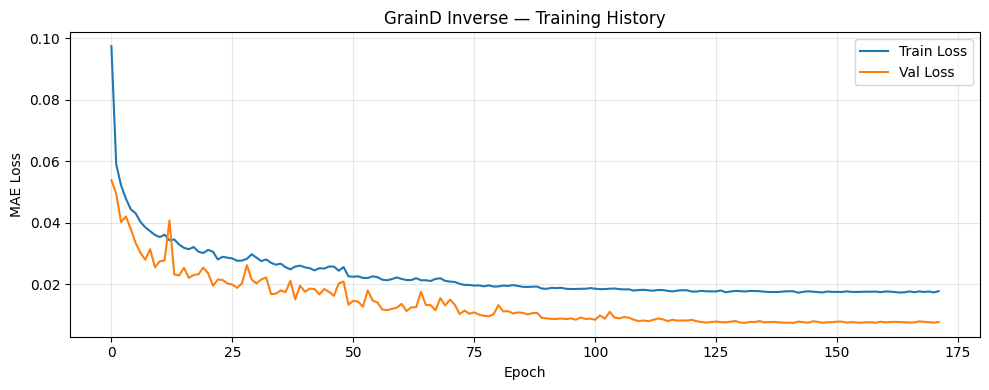

In [25]:
# ══════════════════════════════════════════════════════
# CELL 9 — Evaluation
# ══════════════════════════════════════════════════════
DIM_NAMES = ['Length', 'Diameter', 'Slot_Offset', 'Throat_Diameter', 'Exit_Diameter']

y_pred_s = inverse_model.predict([yt_te_s, yp_te_s, ys_te_s], verbose=0)
y_pred   = s_X.inverse_transform(y_pred_s)
y_actual = X_test

print("\n--- Grain-D Inverse Model Evaluation ---")
for i, col in enumerate(DIM_NAMES):
    mae  = np.mean(np.abs(y_pred[:, i] - y_actual[:, i]))
    mape = np.mean(np.abs(
        (y_pred[:, i] - y_actual[:, i]) / (y_actual[:, i] + 1e-8)
    )) * 100
    print(f"  {col:<20}: MAE = {mae:.4f}  |  MAPE = {mape:.2f}%")

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('GrainD Inverse — Training History')
plt.xlabel('Epoch'); plt.ylabel('MAE Loss')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


🎯 MC Dropout Uncertainty — Sample #100
Dimension             Predicted       ±σ     Actual     Err% Confidence
Length                   79.994    0.000     80.000     0.0%   🟢 High
Diameter                 10.014    0.001     10.000     0.1%   🟢 High
Slot_Offset               2.476    0.002      2.500     1.0%   🟢 High
Throat_Diameter           1.800    0.013      1.800     0.0%   🟢 High
Exit_Diameter             2.698    0.009      2.700     0.1%   🟢 High


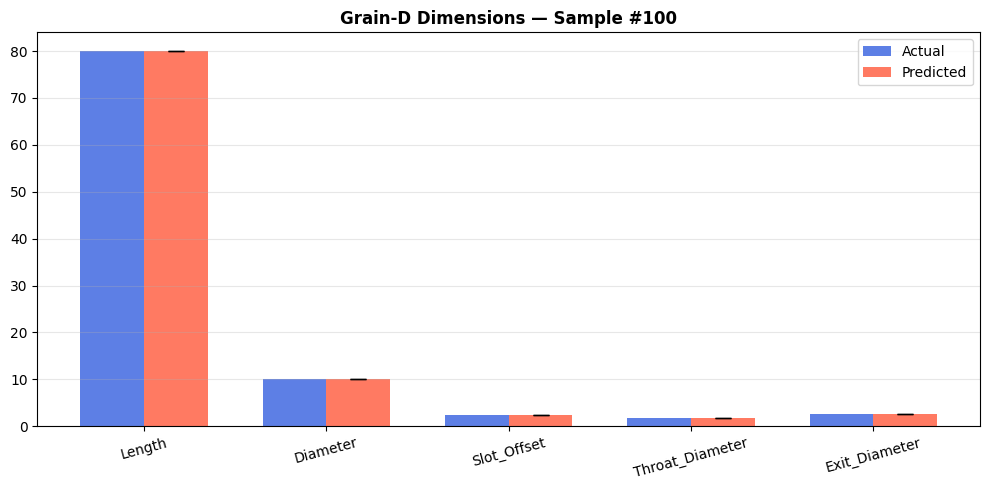


🎯 MC Dropout Uncertainty — Sample #1
Dimension             Predicted       ±σ     Actual     Err% Confidence
Length                   21.913    0.000     20.000     9.6%   🟢 High
Diameter                 19.887    0.000     20.000     0.6%   🟢 High
Slot_Offset               4.205    0.004      4.000     5.1%   🟢 High
Throat_Diameter           1.495    0.018      1.500     0.4%   🟢 High
Exit_Diameter             2.244    0.013      2.250     0.3%   🟢 High


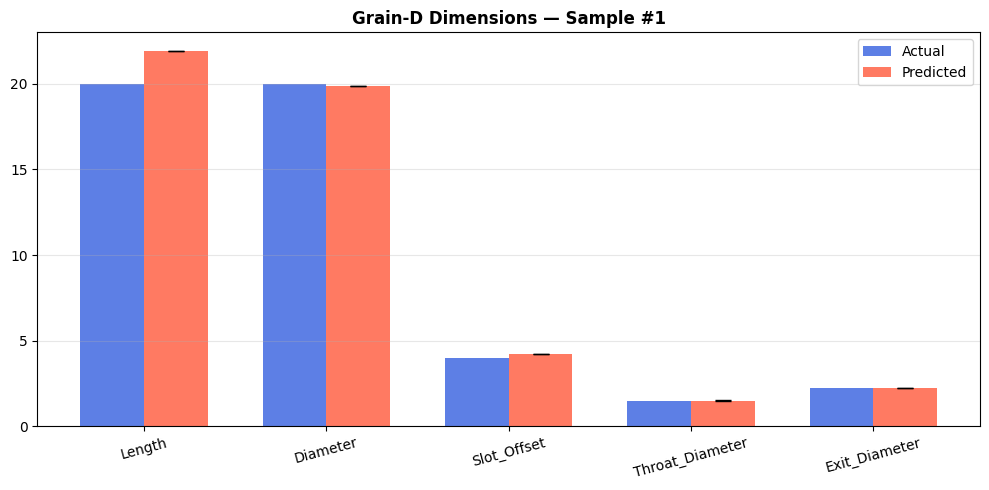


🎯 MC Dropout Uncertainty — Sample #5
Dimension             Predicted       ±σ     Actual     Err% Confidence
Length                   70.454    0.000     70.000     0.6%   🟢 High
Diameter                 15.979    0.001     16.000     0.1%   🟢 High
Slot_Offset               5.481    0.002      5.500     0.3%   🟢 High
Throat_Diameter           1.905    0.010      1.900     0.2%   🟢 High
Exit_Diameter             2.860    0.007      2.850     0.3%   🟢 High


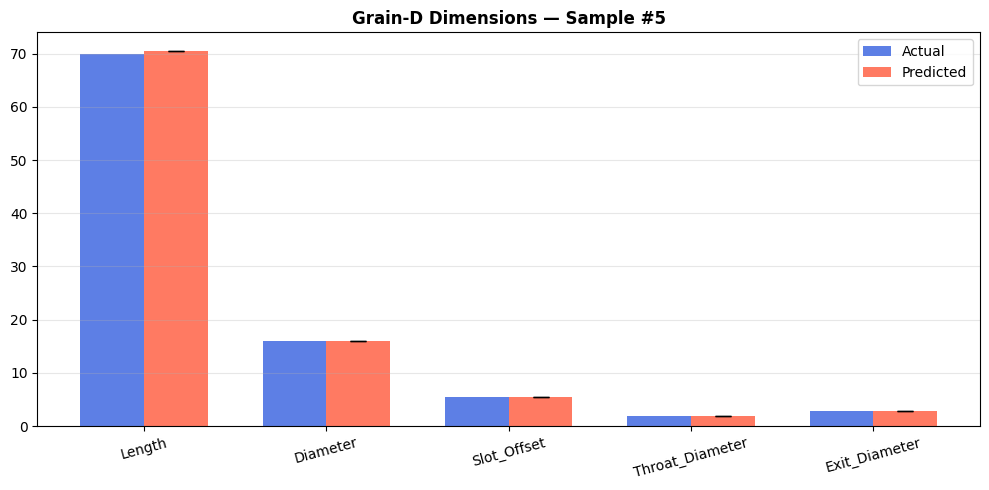

In [31]:
# ══════════════════════════════════════════════════════
# CELL 10 — MC Dropout (نفس كود BATES بالظبط)
# ══════════════════════════════════════════════════════
def mc_predict(t_in, p_in, s_in, n_iter=200):
    t_tensor = tf.constant(t_in, dtype=tf.float32)
    p_tensor = tf.constant(p_in, dtype=tf.float32)
    s_tensor = tf.constant(s_in, dtype=tf.float32)

    preds = []
    for _ in range(n_iter):
        out = inverse_model([t_tensor, p_tensor, s_tensor], training=True)
        preds.append(out.numpy())

    preds_arr = np.stack(preds, axis=0)
    return preds_arr.mean(axis=0), preds_arr.std(axis=0)


def show_uncertainty(sample_idx=0):
    t_s = yt_te_s[sample_idx:sample_idx+1]
    p_s = yp_te_s[sample_idx:sample_idx+1]
    s_s = ys_te_s[sample_idx:sample_idx+1]
    actual = X_test[sample_idx]

    pred_mean_s, pred_std_s = mc_predict(t_s, p_s, s_s, n_iter=200)
    pred_vals = s_X.inverse_transform(pred_mean_s)[0]
    pred_unc  = pred_std_s[0] * s_X.scale_

    print(f"\n🎯 MC Dropout Uncertainty — Sample #{sample_idx}")
    print("=" * 72)
    print(f"{'Dimension':<20} {'Predicted':>10} {'±σ':>8} {'Actual':>10} "
          f"{'Err%':>8} {'Confidence'}")
    print("=" * 72)
    for i, name in enumerate(DIM_NAMES):
        err  = abs(pred_vals[i] - actual[i]) / (actual[i] + 1e-9) * 100
        cv   = pred_unc[i] / (abs(pred_vals[i]) + 1e-9) * 100
        conf = "🟢 High" if cv < 5 else ("🟡 Medium" if cv < 15 else "🔴 Low")
        print(f"{name:<20} {pred_vals[i]:>10.3f} {pred_unc[i]:>8.3f} "
              f"{actual[i]:>10.3f} {err:>7.1f}%   {conf}")
    print("=" * 72)

    fig, ax = plt.subplots(figsize=(10, 5))
    x, w = np.arange(5), 0.35
    ax.bar(x-w/2, actual,    w, label='Actual',    color='royalblue', alpha=0.85)
    ax.bar(x+w/2, pred_vals, w, label='Predicted', color='tomato',    alpha=0.85,
           yerr=pred_unc, capsize=6, error_kw={'linewidth': 2})
    ax.set_xticks(x); ax.set_xticklabels(DIM_NAMES, rotation=15)
    ax.set_title(f'Grain-D Dimensions — Sample #{sample_idx}', fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(f'grainD_uncertainty_{sample_idx}.png', dpi=150)
    plt.show()


show_uncertainty(100)
show_uncertainty(1)
show_uncertainty(5)


  🔩 Predicted Grain-D Dimensions
  Length         : 21.6423 cm
  Diameter       : 17.6535 cm
  Slot_Offset    : 5.7545 cm
  Throat_Diameter: 0.8824 cm
  Exit_Diameter  : 1.3284 cm


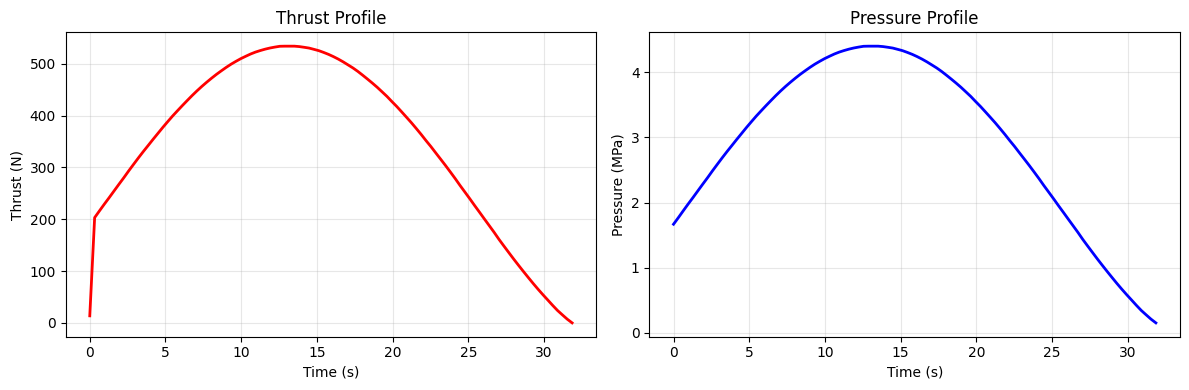

In [30]:
# ══════════════════════════════════════════════════════
# CELL 13 — Inference من ملف (نفس BATES مع تعديل الأعمدة)
# ══════════════════════════════════════════════════════
def predict_dimensions_from_file(file_path):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    # ── قراءة الملف ──
    if file_path.endswith(('.xlsx', '.xls')):
        df = pd.read_excel(file_path)
    else:
        df = pd.read_csv(file_path, sep=None, engine='python',
                         encoding='latin1', on_bad_lines='skip')

    # ── Smart column detection (نفس BATES) ──
    col_map = {}
    for col in df.columns:
        c = str(col).lower().replace(' ','').replace('_','').replace('(','').replace(')','')
        if 'time' in c:           col_map['time']     = col
        elif 'thrust' in c:       col_map['thrust']   = col
        elif 'pressure' in c:     col_map['pressure'] = col
        elif 'isp' in c:          col_map['isp']      = col

    if not all(k in col_map for k in ['time', 'thrust', 'pressure']):
        raise ValueError(f"Columns not found. Available: {list(df.columns)}")

    df = df.sort_values(col_map['time']).dropna(
        subset=[col_map['time'], col_map['thrust'], col_map['pressure']]
    )

    t        = df[col_map['time']].values.astype(float)
    thrust   = df[col_map['thrust']].values.astype(float)
    pressure = df[col_map['pressure']].values.astype(float)

    if len(thrust) > 7:
        thrust   = savgol_filter(thrust,   window_length=7, polyorder=3)
        pressure = savgol_filter(pressure, window_length=7, polyorder=3)

    x_new        = np.linspace(t[0], t[-1], 100)
    thrust_100   = interp1d(t, thrust,   kind='linear', fill_value='extrapolate')(x_new)
    pressure_100 = interp1d(t, pressure, kind='linear', fill_value='extrapolate')(x_new)

    burn_time     = t[-1]
    max_thrust    = np.max(thrust)
    total_impulse = np.trapezoid(thrust, t)
    isp           = df[col_map['isp']].iloc[0] if 'isp' in col_map else 220.0

    scalars = np.array([isp, total_impulse, burn_time, max_thrust])

    t_sc = s_yt.transform(thrust_100.reshape(1, -1))
    p_sc = s_yp.transform(pressure_100.reshape(1, -1))
    s_sc = s_ys.transform(scalars.reshape(1, -1))

    pred_sc   = inverse_model.predict([t_sc, p_sc, s_sc], verbose=0)
    pred_dims = s_X.inverse_transform(pred_sc)[0]
    pred_dims = np.maximum(pred_dims, 0.1)

    print("\n" + "="*50)
    print("  🔩 Predicted Grain-D Dimensions")
    print("="*50)
    labels = ['Length         ', 'Diameter       ',
              'Slot_Offset    ', 'Throat_Diameter', 'Exit_Diameter  ']
    for label, val in zip(labels, pred_dims):
        print(f"  {label}: {val:.4f} cm")
    print("="*50)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(x_new, thrust_100,   color='red',  lw=2)
    axes[0].set_title('Thrust Profile'); axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Thrust (N)');    axes[0].grid(True, alpha=0.3)
    axes[1].plot(x_new, pressure_100, color='blue', lw=2)
    axes[1].set_title('Pressure Profile'); axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Pressure (MPa)');  axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    return dict(zip(DIM_NAMES, pred_dims))


# ── تشغيل ──
results = predict_dimensions_from_file(
    '/kaggle/input/datasets/mahmoudabdelrazek11/fffffffffffffff/182.0.xlsx'
)

In [29]:
# ══════════════════════════════════════════════════════
# CELL 12 — Save
# ══════════════════════════════════════════════════════
inverse_model.save('GrainD_inverse_model.keras')
joblib.dump(s_X,  'grainD_inv_scaler_dims.pkl')
joblib.dump(s_yt, 'grainD_inv_scaler_thrust.pkl')
joblib.dump(s_yp, 'grainD_inv_scaler_pressure.pkl')
joblib.dump(s_ys, 'grainD_inv_scaler_scalars.pkl')
print("✅ Model + Scalers saved")

✅ Model + Scalers saved
